# LAB 03: FEATURE DETECTION AND IMAGE MATCHING
Sinh viên: Nguyễn Văn Tùng Dương

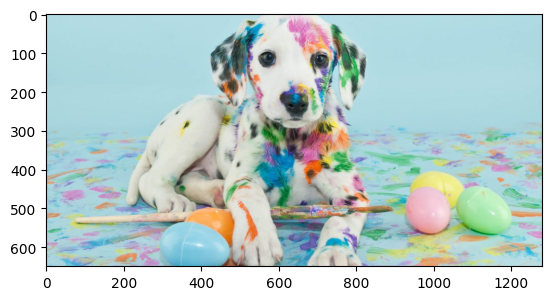

In [2]:
import cv2
import matplotlib.pyplot as TungDuong

# Đọc file ảnh đầu vào cat.jpg
img = cv2.imread('cat.jpg')
# Chuyển đổi định dạng màu từ BGR sang RGB
img = img[:,:,::-1]
TungDuong.imshow(img)
TungDuong.show()


Thực hành xử lý ảnh trong miền tần số: - Fast Fourier Transform (FFT) algorithm để phát hiện ảnh mờ.

Sử dụng đoạn code sau cho DFT, trình bày ý nghĩa của từng dòng lệnh.

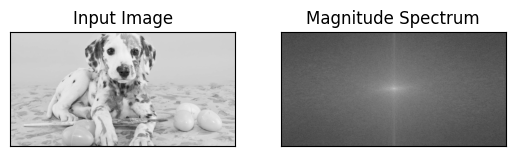

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as TungDuong

# Đọc bức ảnh ảnh gốc (hinh1) với tuỳ chọn 0 để đọc ở dạng ảnh xám (grayscale)
img = cv2.imread('cat.jpg', 0)
# Biến đổi không gian dữ liệu sang ma trận ma trận kiểu Float 32
img_float32 = np.float32(img)

# Dùng hàm dft có sẵn của CV2 để biến đổi ảnh sang tần số Fourier (bản số phức)
dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)
# Dịch chuyển các thành phần có tần số 0 (DC component) vào trung tâm của không gian tần số
dft_shift = np.fft.fftshift(dft)

# Đưa về thang logarit và tính biên độ spectrum (sau khi dịch chuyển dft_shift). Nhân 20 lần để khuếch đại ánh sáng, tăng độ tương phản của spectrum
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]))

# Thiết lập vị trí hiển thị bức ảnh gốc là ô bên trái (thuộc 1 màn gồm 1 dòng, 2 cột)
TungDuong.subplot(121), TungDuong.imshow(img, cmap='gray')
# Xoá nhãn và gán tên cho đồ thị
TungDuong.title('Input Image'), TungDuong.xticks([]), TungDuong.yticks([])

# Thiết lập vị trí hiển thị bức ảnh Fourier ở ô bên phải
TungDuong.subplot(122), TungDuong.imshow(magnitude_spectrum, cmap='gray')
# Xóa nhãn và gán tên cho đồ thị phổ
TungDuong.title('Magnitude Spectrum'), TungDuong.xticks([]), TungDuong.yticks([])

# Đẩy các đồ thị ra màn hình
TungDuong.show()


Sử dụng Fast Fourier Transform (FFT) Magnitude algorithm để phát hiện ảnh mờ

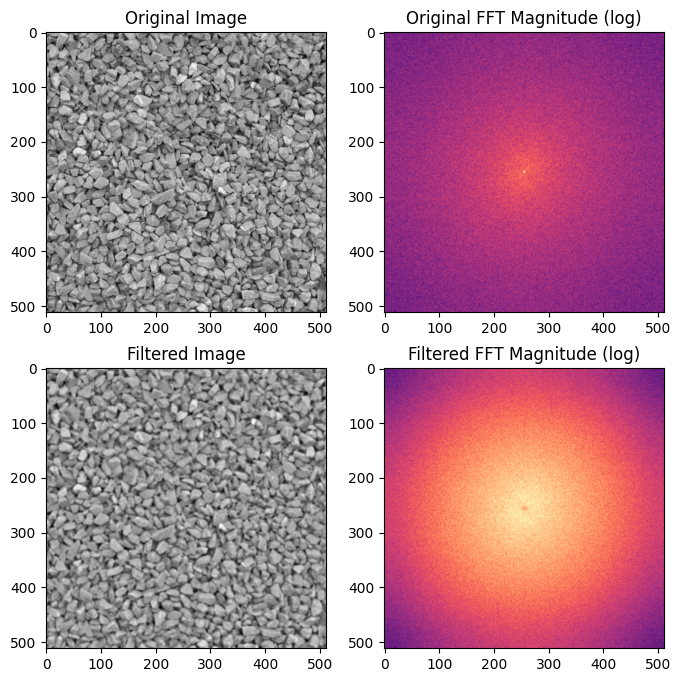

In [4]:
import matplotlib.pyplot as TungDuong
import numpy as np
from skimage.data import gravel
from skimage.filters import difference_of_gaussians, window
from scipy.fft import fftn, fftshift

image = gravel()
wimage = image * window('hann', image.shape)  # window image to improve FFT
filtered_image = difference_of_gaussians(image, 1, 12)
filtered_wimage = filtered_image * window('hann', image.shape)

im_f_mag = fftshift(np.abs(fftn(wimage)))
fim_f_mag = fftshift(np.abs(fftn(filtered_wimage)))

fig, ax = TungDuong.subplots(nrows=2, ncols=2, figsize=(8, 8))
ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 1].imshow(np.log(im_f_mag), cmap='magma')
ax[0, 1].set_title('Original FFT Magnitude (log)')
ax[1, 0].imshow(filtered_image, cmap='gray')
ax[1, 0].set_title('Filtered Image')
ax[1, 1].imshow(np.log(fim_f_mag), cmap='magma')
ax[1, 1].set_title('Filtered FFT Magnitude (log)')

TungDuong.show()


Thực hành Harris Corner Detection

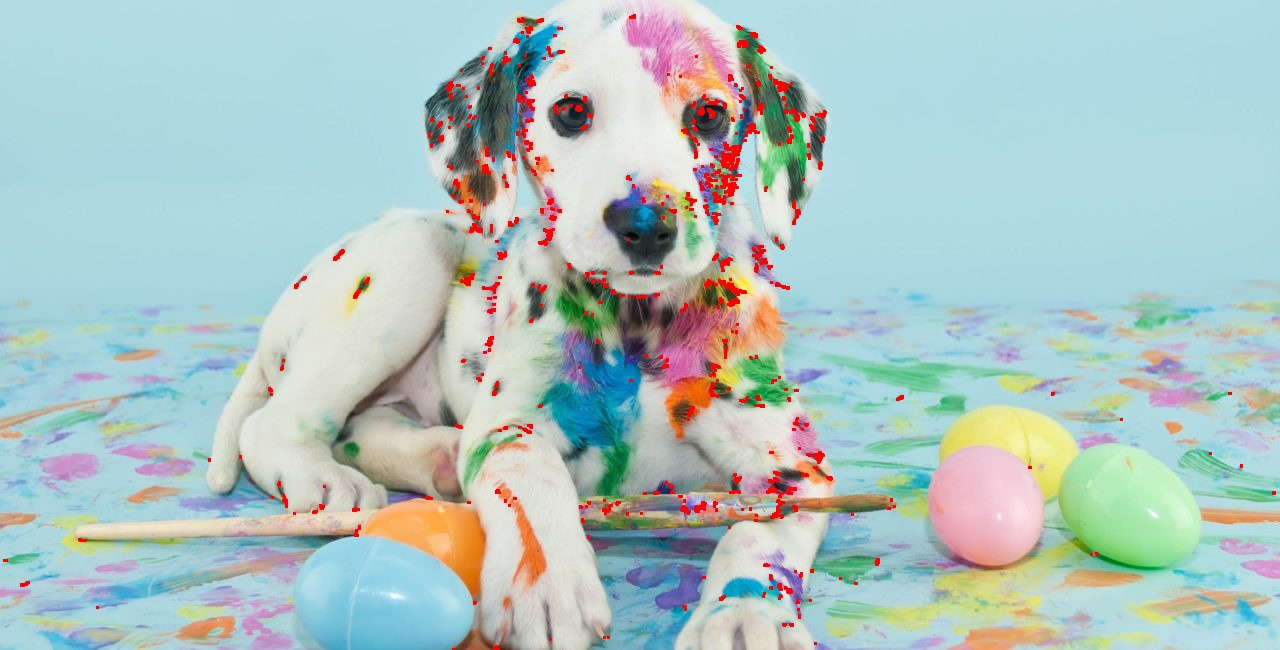

In [5]:
import cv2
import numpy as np
from IPython.display import Image

def detect_corner(image_path, blockSize=2, ksize=3, k=0.04, threshold=0.01):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, blockSize, ksize, k)
    
    # result is dilated for marking the corners, not important
    dst = cv2.dilate(dst, None)
    
    # Threshold for an optimal value, it may vary depending on the image.
    img[dst > threshold * dst.max()] = [0, 0, 255]
    cv2.imwrite('example.jpg', img)
    # Return string path to standardise display with Image instead of numpy array object
    return 'example.jpg'

out_path = detect_corner('cat.jpg', blockSize=2, ksize=5, k=0.04, threshold=0.005)
Image(out_path)


Thử lại thuật toán góc bằng OpenCV hiển thị cơ bản

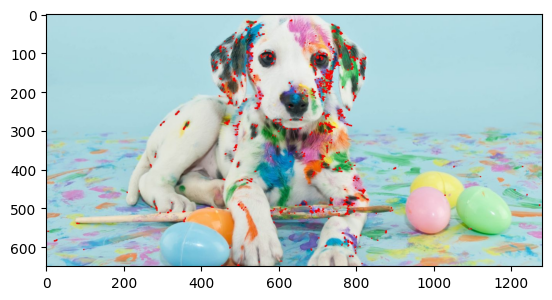

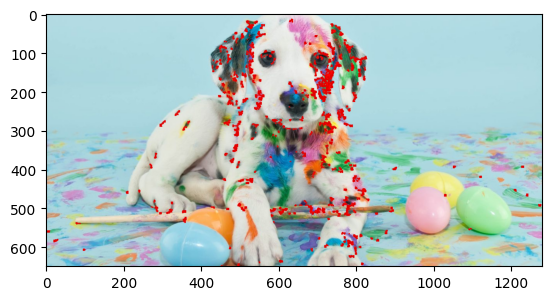

In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as TungDuong

img = cv2.imread('example.jpg')
TungDuong.imshow(img[:,:,::-1])
TungDuong.show()

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

dst = cv2.cornerHarris(gray,2,3,0.04)
dst = cv2.dilate(dst,None)

img[dst>0.01*dst.max()] = [0,0,225]
TungDuong.figure()
TungDuong.imshow(img[:,:,::-1])
TungDuong.show()
